In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

In [3]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)

In [6]:
print(df.duplicated().sum())

0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object


In [9]:
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")

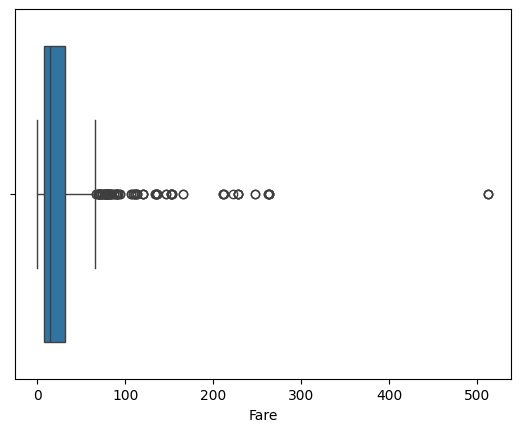

In [10]:
sns.boxplot(x=df["Fare"])
plt.show()

In [11]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [12]:
df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

In [13]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [14]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [15]:
print(df.head())

   PassengerId Survived Pclass                                          Name  \
0            1        0      3                       Braund, Mr. Owen Harris   
2            3        1      3                        Heikkinen, Miss. Laina   
3            4        1      1  Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5        0      3                      Allen, Mr. William Henry   
5            6        0      3                              Moran, Mr. James   

   Sex        Age  SibSp  Parch            Ticket     Fare  Embarked_Q  \
0    0  22.000000      1      0         A/5 21171   7.2500       False   
2    1  26.000000      0      0  STON/O2. 3101282   7.9250       False   
3    1  35.000000      1      0            113803  53.1000       False   
4    0  35.000000      0      0            373450   8.0500       False   
5    0  29.699118      0      0            330877   8.4583        True   

   Embarked_S  
0        True  
2        True  
3        True  
4        T

In [16]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  775 non-null    int64   
 1   Survived     775 non-null    category
 2   Pclass       775 non-null    category
 3   Name         775 non-null    str     
 4   Sex          775 non-null    int64   
 5   Age          775 non-null    float64 
 6   SibSp        775 non-null    int64   
 7   Parch        775 non-null    int64   
 8   Ticket       775 non-null    str     
 9   Fare         775 non-null    float64 
 10  Embarked_Q   775 non-null    bool    
 11  Embarked_S   775 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(2)
memory usage: 57.6 KB
None


In [17]:
df.to_csv("cleaned_titanic.csv", index=False)
print("Data Cleaning Completed")

Data Cleaning Completed
